# Week 5


### Setup

In [54]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from PIL import Image
from sklearn.metrics import classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
test_dir = "/content/drive/MyDrive/AI/workshop5/FruitinAmazon/FruitinAmazon/test"
train_dir ="/content/drive/MyDrive/AI/workshop5/FruitinAmazon/FruitinAmazon/train"

### Data Understanding and Visualization

#### 1. Load and visualize images from a dataset stored in directories, where each subdirectory represents a class.

Number of classes: 6
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


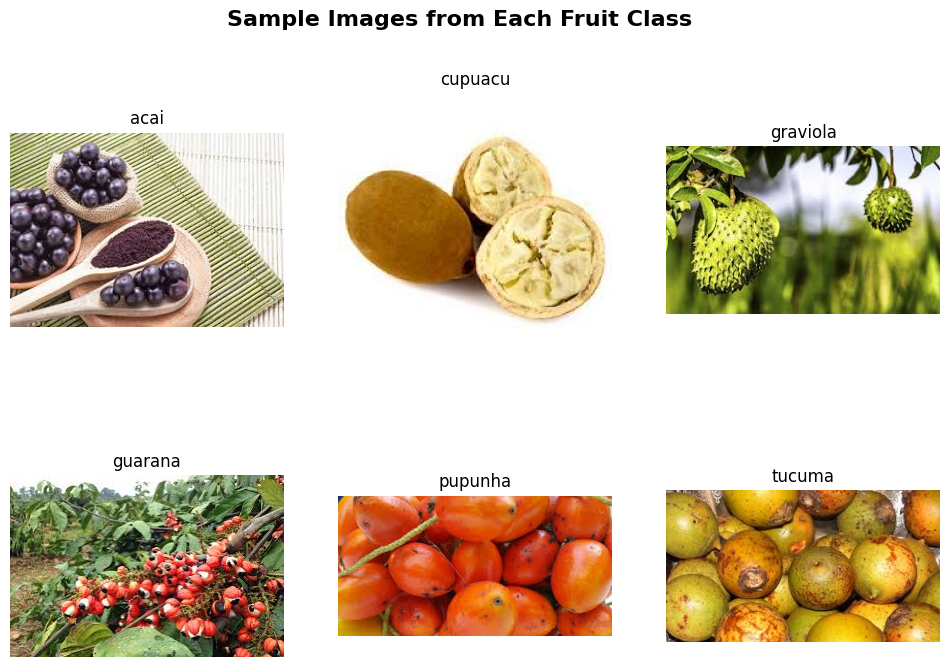

Figure saved: task1_sample_images.png


In [71]:
# Get sorted list of class directories from the train folder
class_dirs = sorted(os.listdir(train_dir))
num_classes = len(class_dirs)
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_dirs}")

# Select one image randomly from each class
sample_images = {}
for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    images = [f for f in os.listdir(cls_path) if not f.startswith('.')]
    chosen = random.choice(images)
    sample_images[cls] = os.path.join(cls_path, chosen)

cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
fig.suptitle('Sample Images from Each Fruit Class', fontsize=16, fontweight='bold')

for idx, (cls, img_path) in enumerate(sample_images.items()):
    r, c = divmod(idx, cols)
    img = mpimg.imread(img_path)
    axes[r, c].imshow(img)
    axes[r, c].set_title(cls, fontsize=12)
    axes[r, c].axis('off')

plt.savefig('task1_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: task1_sample_images.png")

#### Check for Corrupted image

In [72]:
def check_and_remove_corrupted_images(directory):
    corrupted = []
    for cls in os.listdir(directory):
        cls_path = os.path.join(directory, cls)
        if not os.path.isdir(cls_path):
            continue
        for img_name in os.listdir(cls_path):
            image_path = os.path.join(cls_path, img_name)
            try:
                with Image.open(image_path) as img:
                    img.verify()
            except (IOError, SyntaxError):
                corrupted.append(image_path)
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")
    if not corrupted:
        print("No corrupted images found.")
    else:
        print(f"\nTotal corrupted images removed: {len(corrupted)}")
    return corrupted

print("Checking train directory...")
corrupted_train = check_and_remove_corrupted_images(train_dir)

print("\nChecking test directory...")
corrupted_test = check_and_remove_corrupted_images(test_dir)

Checking train directory...
No corrupted images found.

Checking test directory...
No corrupted images found.


### Task 2: Loading and Preprocessing Image Data in keras

In [67]:
img_height = 128
img_width = 128
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2

rescale = tf.keras.layers.Rescaling(1.0 / 255)

# training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=123
)

CLASS_NAMES = train_ds.class_names

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation Datset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=123
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Test Dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

NUM_CLASSES = len(CLASS_NAMES)
print("Class names :", CLASS_NAMES)
print("Num classes :", NUM_CLASSES)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes : 6


### Task 3 - Implementing a CNN

In [73]:
def build_cnn_model(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # Convolutional Block 1
        layers.Conv2D(filters=32, kernel_size=(3, 3),
                      strides=(1, 1), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        # Convolutional Block 2
        layers.Conv2D(filters=32, kernel_size=(3, 3),
                      strides=(1, 1), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        # Fully Connected Network
        layers.Flatten(),
        layers.Dense(64,  activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='CNN_FruitClassifier')

    return model

model = build_cnn_model(
    input_shape=(img_height, img_width, 3),
    num_classes=NUM_CLASSES
)
model.summary()

Model: "CNN_FruitClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

### Task 4 - Compiling the model

In [74]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Training The model

In [75]:
# callbacks
checkpoint_cb = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# implement early stopping
early_stop_cb = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Training
history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb],
    verbose=1
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.2826 - loss: 1.9241
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 413ms/step - accuracy: 0.2778 - loss: 1.8918 - val_accuracy: 0.0000e+00 - val_loss: 1.6541
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.2201 - loss: 1.7125
Epoch 2: val_accuracy improved from 0.00000 to 0.16667, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 360ms/step - accuracy: 0.1944 - loss: 1.7183 - val_accuracy: 0.1667 - val_loss: 1.7169
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.4451 - loss: 1.4962
Epoch 3: val_accuracy improved from 0.16667 to 0.61111, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 371ms/step - accuracy: 0.4444 - loss: 1.4466 - val_accuracy: 0.

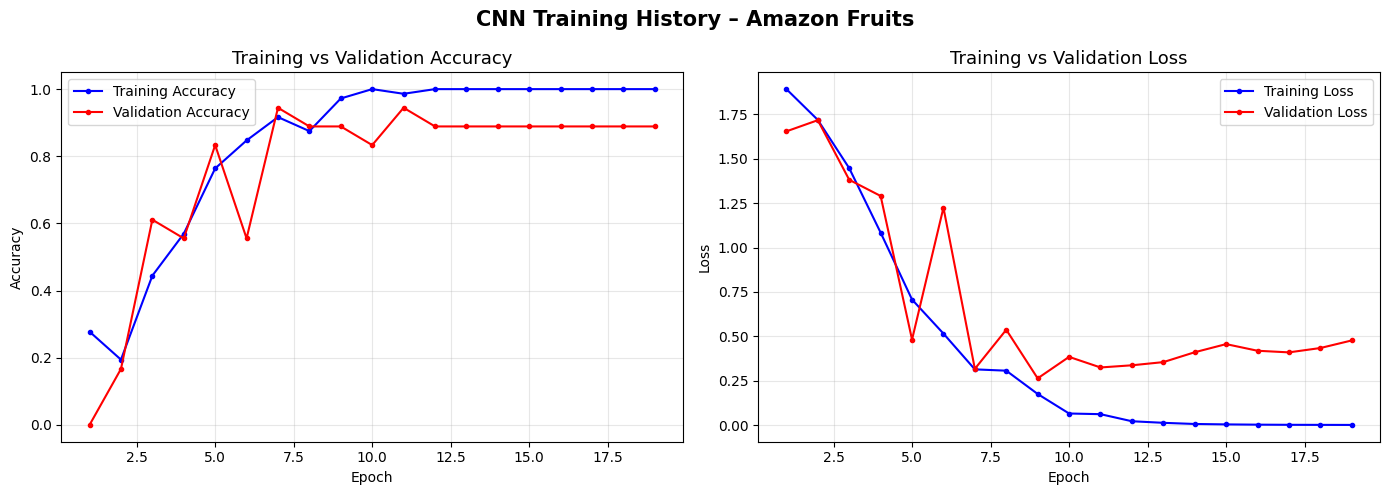

Saved: training_history.png


In [76]:
# Training and and Validation curve
def plot_history(history):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs   = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, acc,     'b-o', markersize=3, label='Training Accuracy')
    ax1.plot(epochs, val_acc, 'r-o', markersize=3, label='Validation Accuracy')
    ax1.set_title('Training vs Validation Accuracy', fontsize=13)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, loss,     'b-o', markersize=3, label='Training Loss')
    ax2.plot(epochs, val_loss, 'r-o', markersize=3, label='Validation Loss')
    ax2.set_title('Training vs Validation Loss', fontsize=13)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.suptitle('CNN Training History – Amazon Fruits', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: training_history.png")

plot_history(history)

### Task 5 - Evaluate the model

In [77]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7667 - loss: 0.7636

Test Loss    : 0.7636
Test Accuracy: 0.7667


### Task 6 - Save and reload the model

In [ ]:
model.save("/content/drive/MyDrive/AI/workshop5/workshop5.h5")

loaded_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/AI/workshop5/workshop5.h5"
)

# Re-evaluate
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f"Test Loss    : {loaded_loss:.4f}")
print(f"Test Accuracy: {loaded_acc:.4f}")

Model saved to week5_model.h5


Model loaded successfully
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.7667 - loss: 0.7636
Test Loss    : 0.7636
Test Accuracy: 0.7667


### Prediction and Classification Report

In [79]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("True labels     :", y_true)
print("Predicted labels:", y_pred)

True labels     : [0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 3 3 3 3 3 4 4 4 4 4 5 5 5 5 5]
Predicted labels: [1 1 0 0 0 1 1 5 5 1 2 2 2 2 2 4 5 3 3 3 4 4 4 4 4 5 2 5 5 5]


In [80]:
# Classification Report
report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    digits=2
)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

        acai       1.00      0.60      0.75         5
     cupuacu       0.60      0.60      0.60         5
    graviola       0.83      1.00      0.91         5
     guarana       1.00      0.60      0.75         5
     pupunha       0.83      1.00      0.91         5
      tucuma       0.57      0.80      0.67         5

    accuracy                           0.77        30
   macro avg       0.81      0.77      0.76        30
weighted avg       0.81      0.77      0.76        30



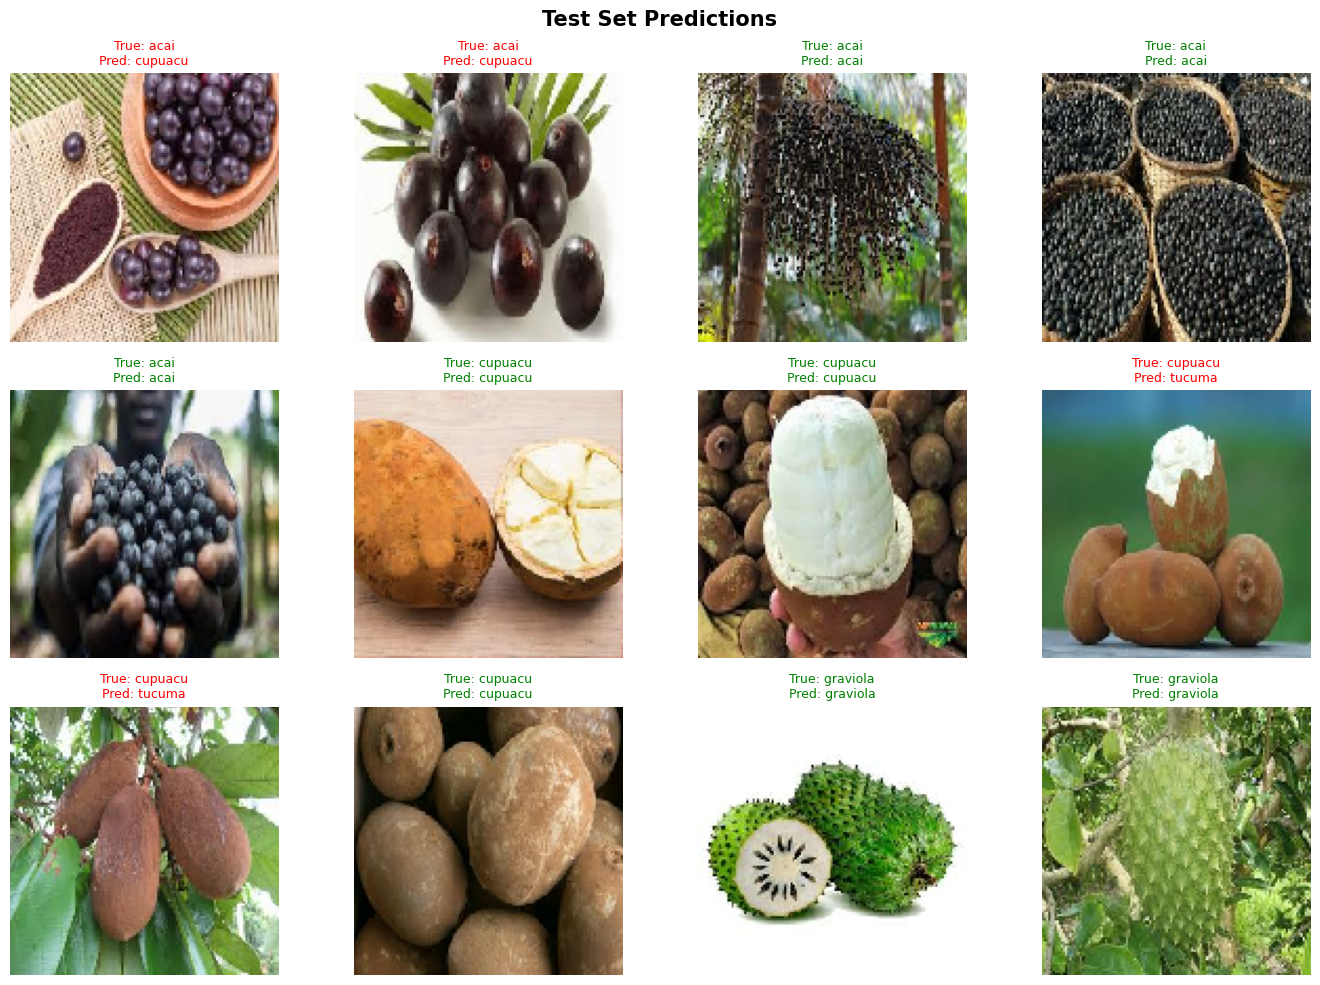

Saved: predictions.png


In [81]:
# Visualise sample predictions (green = correct, red = wrong)
test_imgs_list   = []
test_labels_list = []

for images, labels in test_ds.take(2):
    test_imgs_list.append(images.numpy())
    test_labels_list.append(labels.numpy())

sample_imgs   = np.concatenate(test_imgs_list,   axis=0)[:12]
sample_labels = np.concatenate(test_labels_list, axis=0)[:12]
sample_preds  = np.argmax(loaded_model.predict(sample_imgs, verbose=0), axis=1)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Test Set Predictions', fontsize=15, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    if i >= len(sample_imgs):
        ax.axis('off'); continue
    ax.imshow(sample_imgs[i])
    true_lbl = CLASS_NAMES[sample_labels[i]]
    pred_lbl = CLASS_NAMES[sample_preds[i]]
    color = 'green' if true_lbl == pred_lbl else 'red'
    ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}", color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: predictions.png")